In [2]:
import osmnx as ox
import rasterio
from rasterio.features import rasterize
from shapely.geometry import box
from PIL import Image
import numpy as np
import ee
import requests
from io import BytesIO
import matplotlib.pyplot as plt


ee.Authenticate()
ee.Initialize(project='my-map-segmentation')

width = 1024
height = 1024
tags = {"building": True}

C:\Users\Danila\anaconda3\envs\ds\lib\site-packages\google\api_core\_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [10]:
def get_square_coords( lon:float, lat:float, size_m:int) -> tuple:
    # Константа: сколько метров в одном градусе широты
    meters_per_degree = 111320

    # Смещение по широте (latitude) одинаково везде
    delta_lat = size_m / meters_per_degree

    # Смещение по долготе (longitude) зависит от текущей широты
    import math
    delta_lon = size_m / (meters_per_degree * math.cos(math.radians(lat)))

    # Верхняя левая точка (уже дана)
    top_left = (lon, lat)

    # Нижняя правая точка:
    # Идем "вниз" по широте (минус) и "вправо" по долготе (плюс)
    bottom_right = (lon + delta_lon,lat - delta_lat )

    return top_left, bottom_right

# Метод для получения маски по ббоксу
def get_mask(lon_min: float, lat_max: float, lon_max: float, lat_min: float) -> Image.Image:
    gdf = ox.features_from_bbox((lon_min, lat_max, lon_max, lat_min), tags)
    objects = gdf[gdf.geometry.type.isin(["Polygon", "MultiPolygon"])]

    transform = rasterio.transform.from_bounds(lon_min, lat_max, lon_max, lat_min, width, height)

    bbox = box(lon_min, lat_max, lon_max, lat_min)
    clipped_objects = objects.clip(bbox)
    mask = rasterize(
        [(geom, 1) for geom in clipped_objects.geometry],
        out_shape=(height, width),
        transform=transform,
        fill=0,
        dtype=np.uint8
    )
    img_mask = Image.fromarray(mask * 255)
    return img_mask

def get_mapbox_photo(lon_min: float, lat_max: float, lon_max: float, lat_min: float)

def get_photo(lon_min: float, lat_max: float, lon_max: float, lat_min: float):
    bbox = ee.Geometry.BBox(lon_min, lat_min, lon_max, lat_max)

    # 1. Get the raw image
    img = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
        .filterBounds(bbox) \
        .filterDate('2023-01-01', '2023-12-31') \
        .sort('CLOUDY_PIXEL_PERCENTAGE') \
        .first() \
        .select(['B4', 'B3', 'B2']) \
        .visualize(min=0, max=3000, gamma=1.4)

    url = img.getThumbURL({
        'dimensions': 1024, # Максимальный размер одной из сторон в пикселях
        'region': bbox,
        'format': 'png'
    })
    # Загружаем данные по ссылке прямо в переменную
    response = requests.get(url)
    if response.status_code == 200:
        pil_img = Image.open(BytesIO(response.content))
        return pil_img
    else:
        print("Ошибка загрузки:", response.text)
        return None

In [19]:
top_left, bottom_right = get_square_coords(39.16, 51.69, 10000)

In [20]:
mask = get_mask(top_left[0], top_left[1], bottom_right[0], bottom_right[1])
print('маска')
photo = get_photo(top_left[0], top_left[1], bottom_right[0], bottom_right[1])
print('фото')

маска
фото


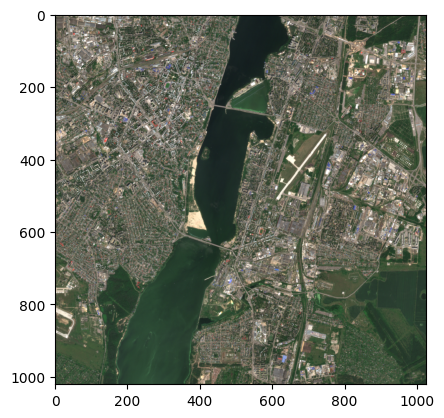

In [21]:
plt.imshow(photo)

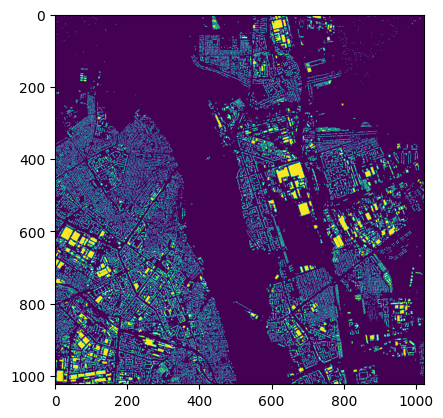

In [22]:
plt.imshow(mask)